In [54]:
# iport library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix , r2_score

import warnings
warnings.filterwarnings('ignore')

In [55]:
df = pd.read_csv('./data2/coin_data.csv')

In [56]:
df.head()

,price,1h,24h,7d,24h_volume,mkt_cap,liquidity
0,17.790168,0.022,0.030,0.055,97440846.0,1.313443e+09,high
1,17.790168,0.024,0.034,0.065,97440846.0,1.313443e+09,high
2,1.000000,-0.001,-0.001,0.000,97440846.0,1.313443e+09,high
3,17.790168,0.018,0.028,0.004,97440846.0,1.313443e+09,high
4,0.999874,-0.001,0.000,-0.000,97440846.0,1.313443e+09,high


In [57]:
df['liquidity'] = df['liquidity'].replace({'low' : 0 , 'high' : 1})

In [58]:
# split into x and y
x = df.drop('liquidity' , axis=1)
y = df['liquidity'].astype('int')

In [59]:
y

0      1
1      1
2      1
3      1
4      1
      ..
995    0
996    0
997    0
998    0
999    0
Name: liquidity, Length: 1000, dtype: int64

In [60]:
# train lest split

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.3 , random_state=9)

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(700, 6)
(700,)
(300, 6)
(300,)


In [61]:
x_train

,price,1h,24h,7d,24h_volume,mkt_cap
775,0.613238,0.003000,0.006000,-0.024000,3.644453e+04,1.854829e+08
975,1.000000,0.010174,0.020006,0.001244,2.642120e+07,7.264325e+07
895,0.237003,-0.001000,0.015000,-0.051000,8.201156e+06,1.091074e+08
337,1.010000,0.001000,0.000000,0.004000,1.793090e+05,1.329540e+08
11,1.000000,-0.002000,0.002000,0.002000,9.744085e+07,1.313443e+09
...,...,...,...,...,...,...
950,0.319453,-0.000000,0.036000,-0.100000,1.930543e+06,8.167597e+07
501,17.790168,0.004000,0.029000,0.034000,9.744085e+07,1.313443e+09
638,17.790168,0.000000,0.007000,-0.036000,6.176845e+06,5.238764e+08
348,13.650000,0.030000,0.044000,0.006000,4.743523e+06,1.284057e+08


In [62]:
y_train

775    0
975    0
895    0
337    0
11     1
      ..
950    0
501    1
638    1
348    0
382    0
Name: liquidity, Length: 700, dtype: int64

## Random forest -
no need to balance data manualy

In [63]:
from sklearn.ensemble import RandomForestClassifier

rfc_model = RandomForestClassifier(class_weight='balanced')
rfc_model.fit(x_train , y_train)

pred = rfc_model.predict(x_test)
accuracy = accuracy_score(y_test , pred)
print(f"accuracy_score by the randomforest model is : {accuracy}")

accuracy_score by the randomforest model is : 1.0


In [64]:
# confusion matrics
confusion_matrix(y_test , pred)


array([[178,   0],
       [  0, 122]])

In [65]:
rfc_model.score(x_test , y_test)

1.0

##Balance the Data first

In [71]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()

# train test split

# x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.25 , random_state=9)

x_train , y_train = smote.fit_resample(x_train , y_train)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(958, 6)
(958,)
(300, 6)
(300,)


In [72]:
y_train.value_counts()

liquidity
0    479
1    479
Name: count, dtype: int64

train test split in balanced data

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(x_train , y_train)
pred = log_model.predict(x_test)
accuracy = accuracy_score(y_test , pred)
print(f"accuracy_score by the logisticregression model is : {accuracy}")
print(f"confusion_matrix by logisticregression : is : \n {confusion_matrix(y_test , pred)}")

accuracy_score by the logisticregression model is : 0.46
confusion_matrix by logisticregression : is : 
 [[ 16 162]
 [  0 122]]


## Gradient boosting model

In [74]:
from sklearn.ensemble import GradientBoostingClassifier

grad_model = GradientBoostingClassifier()
grad_model.fit(x_train , y_train)
pred = grad_model.predict(x_test)
accuracy = accuracy_score(y_test , pred)
print(f"accuracy_score by the gradient boosting model is : {accuracy}")
print(f"confusion_matrix by gradient boosting : is : \n {confusion_matrix(y_test , pred)}")

accuracy_score by the gradient boosting model is : 1.0
confusion_matrix by gradient boosting : is : 
 [[178   0]
 [  0 122]]


In [77]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train , y_train)
pred = knn.predict(x_test)
accuracy = accuracy_score(y_test , pred)
print(f"accuracy_score by the gradient boosting model is : {accuracy}")
print(f"confusion_matrix by gradient boosting : is : \n {confusion_matrix(y_test , pred)}")

accuracy_score by the gradient boosting model is : 0.9966666666666667
confusion_matrix by gradient boosting : is : 
 [[178   0]
 [  1 121]]


## GaussianNB

In [96]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train , y_train)
pred = nb.predict(x_test)
accuracy = accuracy_score(y_test , pred)
print(f"accuracy_score by the gradient boosting model is : {accuracy}")
print(f"confusion_matrix by gradient boosting : is : \n {confusion_matrix(y_test , pred)}")

accuracy_score by the gradient boosting model is : 0.9666666666666667
confusion_matrix by gradient boosting : is : 
 [[169   9]
 [  1 121]]


## SVC

In [80]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(x_train , y_train)
y_pred = svc.predict(x_test)
accuracykn = accuracy_score(y_test , y_pred)
print(f"accuracy_score by the gradient boosting model is : {accuracykn}")
print(f"confusion_matrix by gradient boosting : is : \n {confusion_matrix(y_test , y_pred)}")

accuracy_score by the gradient boosting model is : 0.9966666666666667
confusion_matrix by gradient boosting : is : 
 [[178   0]
 [  1 121]]


since gussiannb model given the accuracy where chance of overfition is low heance go with GussianNB

## tunning -
GussianNB has very few parameters no need og hyper parameter tunning

In [102]:
final_model = GaussianNB()
final_model.fit(x_train , y_train)
pred = final_model.predict(x_test)
accuracy = accuracy_score(y_test , pred)
print(f"accuracy_score by the random forest model is : {accuracy}")
print(f"confusion_matrix by random forest is : \n {confusion_matrix(y_test , pred)}")

accuracy_score by the random forest model is : 0.9666666666666667
confusion_matrix by random forest is : 
 [[169   9]
 [  1 121]]


<Axes: >

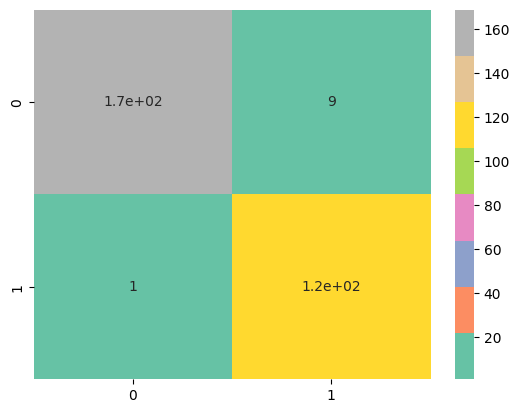

In [103]:
map  = confusion_matrix(y_test , pred)
map = pd.DataFrame(map)
sns.heatmap(map , cmap='Set2' , annot=True)

In [104]:
import joblib
joblib.dump(final_model , 'final_model.pkl')


['final_model.pkl']